In [ ]:
from safetensors.torch import load_file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE
import anndata
import torch

from data_utils.vocab import MicrobiomeVocab

def compute_prevalence_abundance_adata(adata: anndata.AnnData):
    X = adata.X
    if hasattr(X, "toarray"):
        X = X.toarray()

    prevalence = np.mean(X > 0, axis=0)
    abundance = np.mean(X, axis=0)

    return (
        pd.Series(prevalence, index=adata.var_names),
        pd.Series(abundance, index=adata.var_names),
    )


# --------------------
# Choose taxonomy level to color by
# --------------------
def extract_level(taxon, level=1, sep="."):
    """Extract a specific hierarchical level from a taxon string."""
    parts = taxon.split(sep)
    return parts[level] if level < len(parts) else "Unknown"


def plot_umap_taxonomy_colored(
    emb_2d,
    taxa_level_labels,
    ax,
    classes_to_plot=None,
    colormap=plt.cm.tab20,
    point_size=10,
    alpha=0.8,
    colors=None,
    markers=None,
    plot_title=None
):
    taxa_level_labels = np.array(taxa_level_labels)

    # Filter classes if requested
    if classes_to_plot is not None:
        mask = np.isin(taxa_level_labels, classes_to_plot)
        emb_2d = emb_2d[mask]
        taxa_level_labels = taxa_level_labels[mask]
        unique_labels = list(classes_to_plot)
    else:
        unique_labels = list(np.unique(taxa_level_labels))

    # Assign colors
    if colors is None:
        colors = colormap(np.linspace(0, 1, len(unique_labels)))
    # Assign markers
    if markers is None:
        markers = ["o"] * len(unique_labels)

    # Map label → (color, marker)
    label_to_style = {
        label: (colors[i], markers[i])
        for i, label in enumerate(unique_labels)
    }

    for label in unique_labels:
        idxs = (taxa_level_labels == label)
        ax.scatter(
            emb_2d[idxs, 0],
            emb_2d[idxs, 1],
            c=[label_to_style[label][0]],
            marker=label_to_style[label][1],
            label=label,
            s=point_size,
            alpha=alpha,
            edgecolors='none'
        )

    if plot_title:
        ax.set_title(plot_title, fontsize=16)
    ax.tick_params(axis='both', labelsize=18)
    return label_to_style

def plot_umap_highlight_classes(
    emb_2d,
    taxa_level_labels,
    class_to_highlight,
    classes_to_plot=None,
    color_level=None,
    point_size=10,
    alpha=0.8,
    color='red'
):
    """
    Plot UMAP embeddings highlighting selected taxonomic classes.

    Args:
        emb_2d (np.ndarray): 2D embeddings, shape (N, 2).
        taxa_level_labels (list of str): Label for each point.
        class_to_highlight (list of str): Labels to highlight in red.
        color_level (int or None): Optional taxonomy level index for title.
        point_size (int): scatter plot point size.
        alpha (float): transparency for points.
    """
    taxa_level_labels = np.array(taxa_level_labels)
    mask_selected = np.isin(taxa_level_labels, [class_to_highlight])
    
    # Filter classes if requested
    if classes_to_plot is not None:
        mask = np.isin(taxa_level_labels, classes_to_plot)
        emb_2d = emb_2d[mask]
        taxa_level_labels = taxa_level_labels[mask]
        mask_selected = mask_selected[mask]

    plt.figure(figsize=(10, 8))

    # Plot all others in grey
    plt.scatter(
        emb_2d[~mask_selected, 0],
        emb_2d[~mask_selected, 1],
        c="lightgrey",
        label="Other",
        s=point_size,
        alpha=alpha,
        edgecolors="none"
    )

    # Plot selected in red
    plt.scatter(
        emb_2d[mask_selected, 0],
        emb_2d[mask_selected, 1],
        c=color,
        label=class_to_highlight,
        s=point_size,
        alpha=alpha,
        edgecolors="none"
    )

    title = (
        f"UMAP of embeddings, {class_to_highlight} highlighted"
        if color_level is not None
        else "UMAP of embeddings (highlighted classes)"
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3)
    plt.tight_layout()
    plt.show()

def get_embeddings(file_path, vocab_path, adata=None, prevalence_limit=0, abundance_limit=0):
    weights = load_file(file_path)
    emb_matrix = weights["encoder.embedding.weight"]
    emb_matrix = np.array(emb_matrix)  # convert to numpy array

    if adata:
        prevalence, abundance = compute_prevalence_abundance_adata(adata)
        keep_mask = (prevalence >= prevalence_limit) & (abundance >= abundance_limit)

        # Subset AnnData
        full_mask = np.zeros(len(emb_matrix), dtype=bool)
        full_mask[:len(keep_mask)] = keep_mask  # first 4680 are your mask, last 3 stay False
        emb_matrix_filtered = emb_matrix[full_mask, :]
        adata_top_x = adata[:, keep_mask].copy()
        taxa_list = adata_top_x.var_names.tolist()
        taxa_level_labels = np.array([[extract_level(t, level=color_level) for t in taxa_list] for color_level in range(4)])

    else:
        vocab = MicrobiomeVocab.restore_vocab(vocab_path)
        taxa_list = vocab.vocab_list
        taxa_level_labels = np.array([[extract_level(t, level=color_level) for t in taxa_list] for color_level in range(4)])

        emb_matrix_filtered = emb_matrix[:len(taxa_list), :]
    print(emb_matrix_filtered.shape)
    # --------------------
    # Run UMAP
    # --------------------
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=40
    )
    umap_2d = reducer.fit_transform(emb_matrix_filtered)

    # --------------------
    # Run t-SNE
    # --------------------
    tsne = TSNE(
        n_components=2,
        perplexity=10,       # similar to n_neighbors in UMAP
        learning_rate=200,
        metric="cosine",     # can also be "euclidean"
        random_state=40,
        init="pca",          # good starting point for t-SNE
    )
    tsne_2d = tsne.fit_transform(emb_matrix_filtered)
    
    return umap_2d, tsne_2d, taxa_level_labels



In [ ]:
from models import TransformerModel
from data_utils.vocab import MicrobiomeVocab
import json

def get_embeddings_gnn(file_path, graph_data_path, vocab_path, model_config_path):
    weights = load_file(file_path)
    with open(model_config_path, "r") as f:
        model_config = json.load(f)
    model = TransformerModel(**model_config)
    model.load_state_dict(weights)
    
    # get graph data
    graph_data = torch.load(graph_data_path, weights_only=False)
    vocab = MicrobiomeVocab.restore_vocab(vocab_path)
    num_taxa = len(vocab.vocab_list)
    assert num_taxa == len(graph_data.vocabindex_to_nodeindex), "Vocab size does not match graph data"
    
    
    model.eval()
    with torch.no_grad():
        taxa_graph_encoder = model.encoder
        query_vecs = torch.arange(num_taxa)
        query_vecs = query_vecs.unsqueeze(0) # add batch dimension, shape (1, num_taxa)
        node_emb_matrix = taxa_graph_encoder(query_vecs, graph_data)
        node_emb_matrix = node_emb_matrix.squeeze(0).cpu().numpy()  # shape (num_taxa, emb_dim)
    
        
        
    # if adata:
    #     prevalence, abundance = compute_prevalence_abundance_adata(adata)
    #     keep_mask = (prevalence >= prevalence_limit) & (abundance >= abundance_limit)

    # # Subset AnnData
    # full_mask = np.zeros(len(emb_matrix), dtype=bool)
    # full_mask[:len(keep_mask)] = keep_mask  # first 4680 are your mask, last 3 stay False
    # emb_matrix_filtered = emb_matrix[full_mask, :]
        
    # if adata:
    #     adata_top_x = adata[:, keep_mask].copy()
    #     taxa_list = adata_top_x.var_names.tolist()
    #     taxa_level_labels = np.array([[extract_level(t, level=color_level) for t in taxa_list] for color_level in range(4)])

    # get list of taxa_level_labels
    taxa_list = [vocab.itos[i] for i in query_vecs[0].tolist()]
    taxa_level_labels = np.array([[extract_level(t, level=color_level) for t in taxa_list] for color_level in range(4)])
    
    # --------------------
    # Run UMAP
    # --------------------
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=40
    )
    umap_2d = reducer.fit_transform(node_emb_matrix)

    # --------------------
    # Run t-SNE
    # --------------------
    tsne = TSNE(
        n_components=2,
        perplexity=10,       # similar to n_neighbors in UMAP
        learning_rate=200,
        metric="cosine",     # can also be "euclidean"
        random_state=40,
        init="pca",          # good starting point for t-SNE
    )
    tsne_2d = tsne.fit_transform(node_emb_matrix)
    
    return umap_2d, tsne_2d, taxa_level_labels

In [ ]:
file_path_rand = "experiment_saves/no-gnn-1/model_checkpoints/intermediate_checkpoints/epoch_0/model.safetensors"
vocab_path = "experiment_saves/no-gnn-1/model_checkpoints/data_checkpoint/vocab_file.json"
# adata_path = "/project/aip-rahulgk/gutmodel/datasets_newsplit/pretrain.h5ad"
# prevalence, abundance = 0.01, 0.05
# adata = anndata.read_h5ad(adata_path)
umap_2d_rand, tsne_2d_rand, taxa_level_labels = get_embeddings(file_path_rand, vocab_path)

file_path = "experiment_saves/no-gnn-1/model_checkpoints/intermediate_checkpoints/epoch_14/model.safetensors"
umap_2d, tsne_2d, _ = get_embeddings(file_path, vocab_path)

(4296, 128)


/tmp/ipykernel_2946277/397807675.py:159: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  emb_matrix = np.array(emb_matrix)  # convert to numpy array
/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2946277/397807675.py:159: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  emb_matrix = np.array(emb_matrix)  # convert to numpy array
/home/kc

(4296, 128)


In [ ]:
taxa_level_labels.shape

(4, 4296)

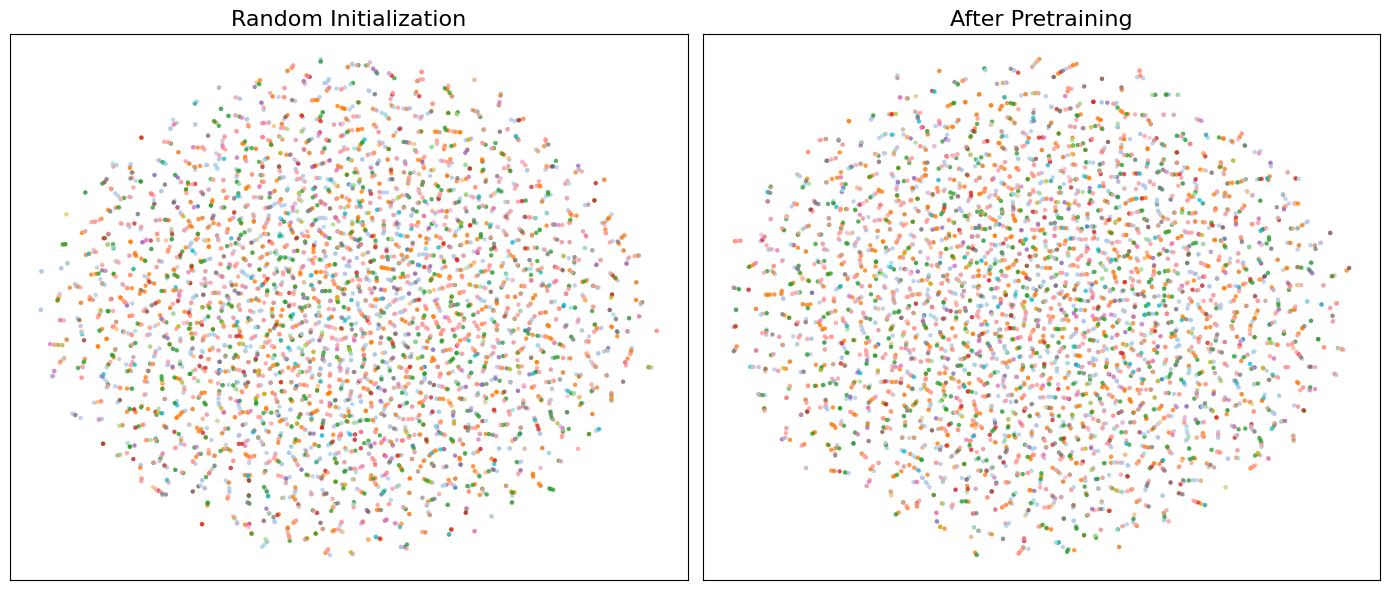

In [62]:
colors = ["orange", "blue", "green", "purple"]
markers = ["^", "o", "s", "D"]  
classes = ["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"]
level = 2
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
# fig.suptitle("UMAP of Taxa Embeddings by Phylum", fontsize=20, y=1.02)

# First plot
label_to_style = plot_umap_taxonomy_colored(
    tsne_2d_rand,
    taxa_level_labels[level],
    ax=axes[0],
    # classes_to_plot=classes,
    # colors=colors,
    # markers=markers,
    plot_title="Random Initialization"
)
axes[0].set_xticks([])
axes[0].set_yticks([])
# Second plot
plot_umap_taxonomy_colored(
    tsne_2d,
    taxa_level_labels[level],
    ax=axes[1],
    # classes_to_plot=classes,
    # colors=colors,
    # markers=markers,
    plot_title="After Pretraining"
)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Shared legend using both color and marker
handles = [
    plt.Line2D(
        [0], [0],
        marker=marker,
        color='w',
        label=label,
        markerfacecolor=color,
        markersize=8,
        linestyle='None'
    )
    for label, (color, marker) in label_to_style.items()
]

# fig.legend(
#     handles=handles,
#     loc='center',
#     bbox_to_anchor=(0.5, 0.8),  # move upward (0.5 is vertical center, so 0.75 is higher)
#     fontsize=12,
#     ncol=1,                      # vertical stack
#     frameon=True,                # draw a box
#     facecolor='white',           # solid background
#     edgecolor='black',           # box border color
#     framealpha=1.0,               # fully opaque
#     handletextpad=0.4,
#     borderaxespad=0.5
# )

plt.tight_layout()
plt.show()


GNN

In [ ]:
file_path_rand = "experiment_saves/gat-1/model_checkpoints/intermediate_checkpoints/epoch_0/model.safetensors"
graphdata_path = "experiment_saves/gat-1/model_checkpoints/data_checkpoint/graph_data.pt"
vocab_path = "experiment_saves/gat-1/model_checkpoints/data_checkpoint/vocab_file.json"
model_config_path = "experiment_saves/gat-1/model_checkpoints/model_config.json"
# adata_path = "/project/aip-rahulgk/gutmodel/remove_redundant_oct24/pretrain.h5ad"
# prevalence, abundance = 0.01, 0.05
# adata = anndata.read_h5ad(adata_path)
umap_2d_rand_gnn, tsne_2d_rand_gnn, taxa_level_labels_gnn = get_embeddings_gnn(file_path_rand, graphdata_path, vocab_path, model_config_path)

file_path = "experiment_saves/gat-1/model_checkpoints/best_model/model.safetensors"
umap_2d_gnn, tsne_2d_gnn, taxa_level_labels_gnn = get_embeddings_gnn(file_path, graphdata_path, vocab_path, model_config_path)

/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


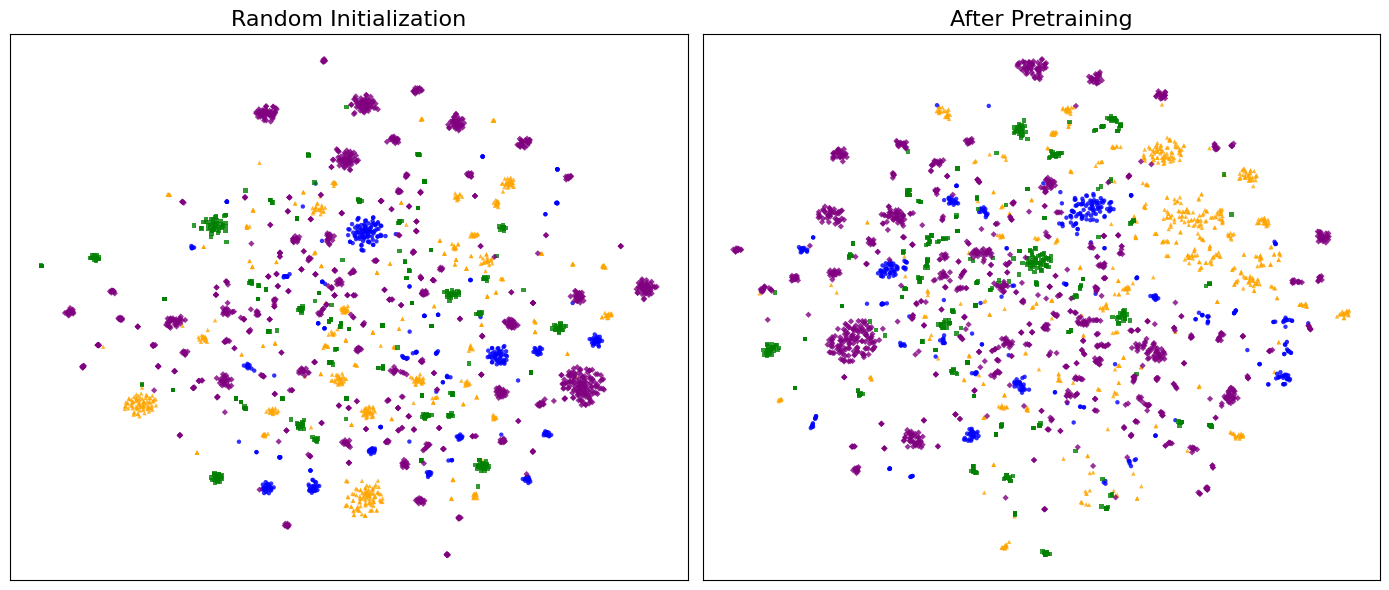

In [ ]:
colors = ["orange", "blue", "green", "purple"]
markers = ["^", "o", "s", "D"]  
classes = ["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"]
level = 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
# fig.suptitle("UMAP of Taxa Embeddings by Phylum", fontsize=20, y=1.02)

# First plot
label_to_style = plot_umap_taxonomy_colored(
    tsne_2d_rand_gnn,
    taxa_level_labels_gnn[level],
    ax=axes[0],
    classes_to_plot=classes,
    colors=colors,
    markers=markers,
    plot_title="Random Initialization"
)
axes[0].set_xticks([])
axes[0].set_yticks([])
# Second plot
label_to_style = plot_umap_taxonomy_colored(
    tsne_2d_gnn,
    taxa_level_labels_gnn[level],
    ax=axes[1],
    classes_to_plot=classes,
    colors=colors,
    markers=markers,
    plot_title="After Pretraining"
)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Shared legend using both color and marker
handles = [
    plt.Line2D(
        [0], [0],
        marker=marker,
        color='w',
        label=label,
        markerfacecolor=color,
        markersize=8,
        linestyle='None'
    )
    for label, (color, marker) in label_to_style.items()
]

# fig.legend(
#     handles=handles,
#     loc='center',
#     bbox_to_anchor=(0.5, 0.8),  # move upward (0.5 is vertical center, so 0.75 is higher)
#     fontsize=12,
#     ncol=1,                      # vertical stack
#     frameon=True,                # draw a box
#     facecolor='white',           # solid background
#     edgecolor='black',           # box border color
#     framealpha=1.0,               # fully opaque
#     handletextpad=0.4,
#     borderaxespad=0.5
# )

plt.tight_layout()
plt.show()


In [ ]:
file_path_rand_gcn = "experiment_saves/gnn-1/model_checkpoints/intermediate_checkpoints/epoch_0/model.safetensors"
graphdata_path_gcn = "experiment_saves/gnn-1/model_checkpoints/data_checkpoint/graph_data.pt"
vocab_path_gcn = "experiment_saves/gnn-1/model_checkpoints/data_checkpoint/vocab_file.json"
model_config_path_gcn = "experiment_saves/gnn-1/model_checkpoints/model_config.json"
# adata_path = "/project/aip-rahulgk/gutmodel/remove_redundant_oct24/pretrain.h5ad"
# prevalence, abundance = 0.01, 0.05
# adata = anndata.read_h5ad(adata_path)
umap_2d_rand_gcn, tsne_2d_rand_gcn, taxa_level_labels_gcn = get_embeddings_gnn(file_path_rand_gcn, graphdata_path_gcn, vocab_path_gcn, model_config_path_gcn)

file_path_gcn = "experiment_saves/gnn-1/model_checkpoints/best_model/model.safetensors"
umap_2d_gcn, tsne_2d_gcn, taxa_level_labels_gcn = get_embeddings_gnn(file_path_gcn, graphdata_path_gcn, vocab_path_gcn, model_config_path_gcn)

/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


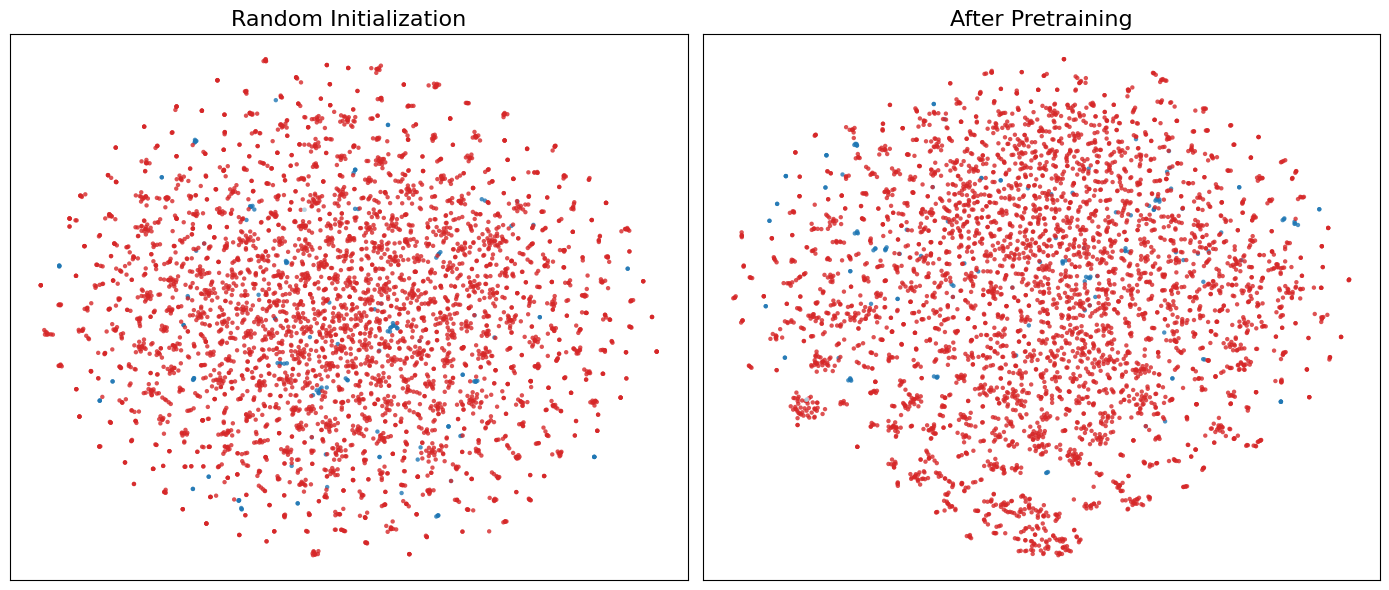

In [ ]:
colors = ["orange", "blue", "green", "purple"]
markers = ["^", "o", "s", "D"]  
classes = ["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"]
level = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
# fig.suptitle("UMAP of Taxa Embeddings by Phylum", fontsize=20, y=1.02)

# First plot
label_to_style = plot_umap_taxonomy_colored(
    tsne_2d_rand_gcn,
    taxa_level_labels_gcn[level],
    ax=axes[0],
    # classes_to_plot=classes,
    # colors=colors,
    # markers=markers,
    plot_title="Random Initialization"
)
axes[0].set_xticks([])
axes[0].set_yticks([])
# Second plot
label_to_style = plot_umap_taxonomy_colored(
    tsne_2d_gcn,
    taxa_level_labels_gcn[level],
    ax=axes[1],
    # classes_to_plot=classes,
    # colors=colors,
    # markers=markers,
    plot_title="After Pretraining"
)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Shared legend using both color and marker
handles = [
    plt.Line2D(
        [0], [0],
        marker=marker,
        color='w',
        label=label,
        markerfacecolor=color,
        markersize=8,
        linestyle='None'
    )
    for label, (color, marker) in label_to_style.items()
]

# fig.legend(
#     handles=handles,
#     loc='center',
#     bbox_to_anchor=(0.5, 0.8),  # move upward (0.5 is vertical center, so 0.75 is higher)
#     fontsize=12,
#     ncol=1,                      # vertical stack
#     frameon=True,                # draw a box
#     facecolor='white',           # solid background
#     edgecolor='black',           # box border color
#     framealpha=1.0,               # fully opaque
#     handletextpad=0.4,
#     borderaxespad=0.5
# )

plt.tight_layout()
plt.show()
